In [99]:
from geostat_isoscapes_tools import utils, geostat_utils, plot_utils
import numpy as np
from pykrige.uk import UniversalKriging
import json
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

sns.set_style('dark')

loading sisal data
-> loading SISAL database
   cleaning samples
loading and cleaning done.
-> converting speleothem data
   linear interpolation failed for 121612 samples, trying to fill missing T with nearest neighbour method
   after linear interpolation and nearest neighbour backup, still no temperature for 64562 samples.
   temperature retrieval finished, starting conversion
conversion done.
sisal dataframe is ready
loading itrace files
This dataset contains  12000  time steps.
   bins of width=2400 months (200 years)
   converting xr to DataFrame (~2 minutes)
done


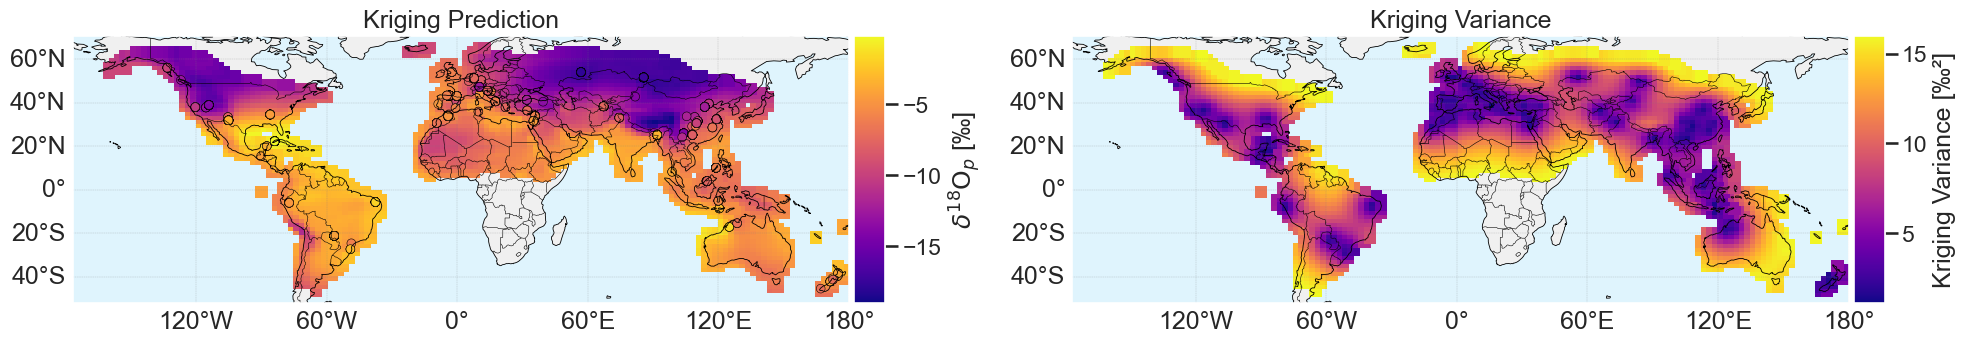

In [ ]:
###### SETUP ######
qty='d18Op_VSMOW_linearized'
res_months=200*12
# vario_path = f'{utils.get_project_root()}/output/variograms/itrace/sim12kyrBP/res2400/maxlag12000000nlags20/trend_multiple_linear_latabs_latReLU_ele_D/sisal_mask/variogram_params_None.json'
vario_path = f'{utils.get_project_root()}/output/variograms/itrace/sim12kyrBP/res2400/maxlag8500000nlags15/trend_multiple_linear_latabs_latReLU_ele_D/no_mask/variogram_params_None.json'

ss_threshold = 16

###### LOAD DATA ######
# SISAL 
data_with_time_slices = geostat_utils.get_sisal_data_for_kriging(res=res_months//12,conversion=qty)

# ITRACE 
itrace_data = geostat_utils.get_preprocessed_itrace_data(data_folder='/media/luluxette/T7_Shield/pdm/iTrace/',res=res_months) # simulation 12k
itrace_times = itrace_data['time'].unique() #type:ignore # thisis the bumber of time steps in itrace df
external_drift_df = itrace_data[itrace_data['time']==itrace_times[-1]].dropna() #type:ignore
external_drift_df['lon']=utils.convert_lon_0_360_to_neg180_180(np.asarray(external_drift_df['lon'].values))
# plot_utils.plot_global_map(external_drift_df,'external drift','d18Op',unit='‰ VSMOW', lat_col='lat',lon_col='lon') # type:ignore
data_to_krige = data_with_time_slices[ (data_with_time_slices['binned_age']==11200)].copy()
# plot_utils.plot_global_map(data_to_krige,'sISAL data to krige - 11-11.2 kyr BP',unit='‰ VSMOW',quantity_col=qty,lat_col='lat',lon_col='lon') # type:ignore
###### VARIOGRAM ######
with open(vario_path, 'r') as f:
    variogram_dict = json.load(f)
# define variogram model
variogram_model = variogram_dict['model_name'] 
variogram_parameters = {
    "sill": variogram_dict['sill'], 
    "range": variogram_dict['range'],  
    "nugget": variogram_dict['nugget']
}
###### EXT DRIFT AT OBS POINTS ######
# Retrieve itrace **at** observation points
lats_obs = data_to_krige['lat']
lons_obs  = data_to_krige['lon']
# Build tree from the grid coordinates
grid_points = np.column_stack((external_drift_df['lat'], external_drift_df['lon']))
tree = cKDTree(grid_points)
# Query nearest grid point for each observation
dists, idxs = tree.query(np.column_stack((lats_obs, lons_obs)))
itrace_at_obs_nn = external_drift_df['d18Op'].values[idxs]
# fig,ax = plot_utils.plot_platecarree_field_and_scatter_on_top(external_drift_df,
#                                                               pd.DataFrame({'lat':lats_obs,'lon':lons_obs,'d18Op':itrace_at_obs_nn}),
#                                                               )
# plt.show()
###### PROJECT IN MERCATOR COORDS ######
# Project data in CRS system for kriging 
data_to_krige['x'],data_to_krige['y'] = geostat_utils.project_coords(data_to_krige['lon'].values,data_to_krige['lat'].values)
external_drift_df['x'],external_drift_df['y'] = geostat_utils.project_coords(external_drift_df['lon'].values,external_drift_df['lat'].values)
itrace_values_xygrid = external_drift_df['d18Op'].values
###### KRIGING ######
# universal kriging object
uk = UniversalKriging(
    x=data_to_krige["x"],
    y=data_to_krige["y"],
    z=data_to_krige[qty],
    variogram_model=variogram_model,
    variogram_parameters=variogram_parameters,
    drift_terms=["specified"],
    specified_drift=[itrace_at_obs_nn]
)
# execute 
z_pred, ss_pred = uk.execute(
    style="points",
    xpoints=external_drift_df['x'],
    ypoints=external_drift_df['y'],
    specified_drift_arrays=[itrace_values_xygrid]
)
# gather results in df
df_pred = pd.DataFrame({'lon': external_drift_df['lon'],
            'lat':external_drift_df['lat'],
            'z_pred':z_pred,
            'ss_pred':ss_pred})
# mask predictions according to a kriging variance threshold
df_pred_masked = df_pred[df_pred['ss_pred']<ss_threshold]
###### PLOTTING ######
fig,axes = plot_utils.plot_ked_platecarree_points(
    df_pred=df_pred_masked,
    df_obs=data_to_krige,               
    value_col=qty,
    cmap='plasma',
    s_pred=80,
    figsize=(20,4),
    adjust_extent=False
) # type:ignore
plt.tight_layout()
# plt.savefig('../output/ked_firsttests/test_fig.png',dpi=500)
plt.show()

### Kriging validation metrics analysis 

In [ ]:
with open(f'{utils.get_project_root()}/data/iTrace_simulations_dict.json', 'r') as f:
    itrace_sims = json.load(f)
sims = dict((k,itrace_sims[k]) for k in ('12','13','14','15','16','17','18','19','20') if k in itrace_sims)
res_months = 12*200
list_crossval_df = []
list_crossval_metrics = [] 
for kyr in sims.keys() :
    for time in range((int(kyr)-1)*1000+res_months//12,int(kyr)*1000+1,res_months//12):
        fp_output = f"{utils.get_project_root()}/output/kriging/run_2026_02_06/res{res_months}/plots_and_metrics/{str(int(time))}yrBP/"
        crossval_df = pd.read_csv(f'{fp_output}crossval_df.csv').reset_index(drop=True)
        crossval_df['time']=time
        with open(fp_output+'crossval_metrics.json', 'r') as f: 
            crossval_metrics = json.load(f)
        list_crossval_df.append(crossval_df)
        list_crossval_metrics.append(pd.DataFrame(crossval_metrics,index=[time]))

crossval_df = pd.concat(list_crossval_df)
crossval_metrics = pd.concat(list_crossval_metrics)

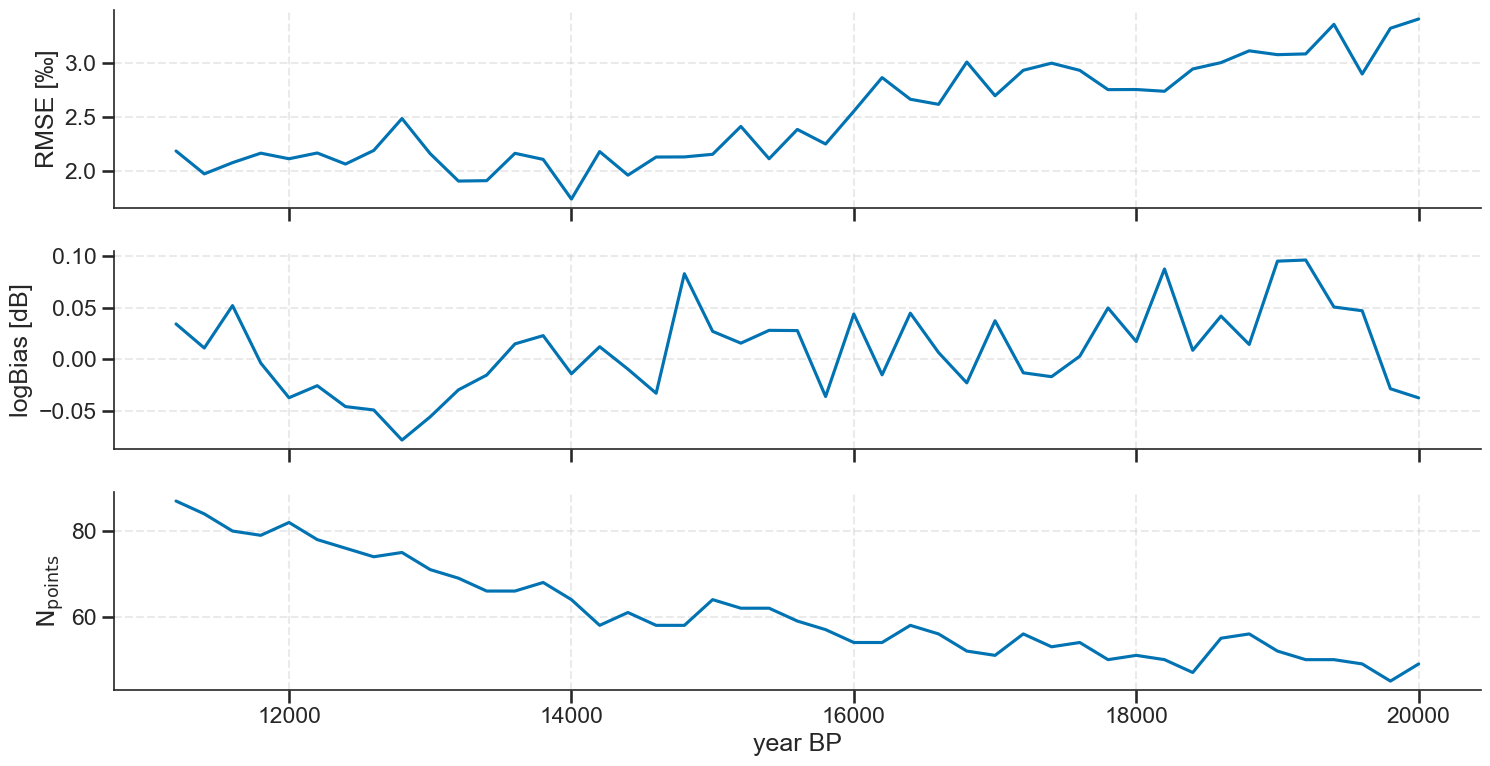

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(context='talk',
                  style='ticks',
                  palette='colorblind',
                  rc={'axes.linewidth':1.2,"grid.alpha":0.3,"grid.linestyle":'--'})

fig, axes = plt.subplots(3,1,figsize=(15,8),sharex=True)

# Scatter plot of irregular points
# axes[0].plot(crossval_metrics.index.values,crossval_metrics['MAE'])
axes[0].plot(crossval_metrics.index.values,crossval_metrics['RMSE'])
axes[0].set_ylabel('RMSE [‰]')
axes[1].plot(crossval_metrics.index.values,crossval_metrics['logbias'])
axes[1].set_ylabel('logBias [dB]')
axes[2].plot(crossval_metrics.index.values,np.array([len(crossval_df[crossval_df.time==t]) for t in crossval_metrics.index.values]))
axes[2].set_ylabel(r'$\text{N}_\text{points}$')
axes[2].set_xlabel('year BP')
axes[0].grid(alpha=0.4)
axes[1].grid(alpha=0.4)
axes[2].grid(alpha=0.4)
sns.despine(top=True,right=True)
plt.tight_layout()
plt.show()

In [98]:
crossval_metrics

,RMSE,MAE,mean_bias,logbias,R_obs_pred,R_pred_res,Kleijnen_null_hypothesis_0.05level,n_points
11200,2.188096,1.629821,-0.062213,0.034290,0.798671,-0.038713,rejected,87
11400,1.977052,1.567171,-0.019875,0.011023,0.811703,-0.027560,rejected,84
11600,2.080510,1.596250,-0.092884,0.052044,0.791624,-0.007434,rejected,80
11800,2.168088,1.635583,0.006167,-0.003528,0.727585,-0.115338,rejected,79
12000,2.116454,1.574431,0.065374,-0.037033,0.732009,-0.098263,rejected,82
12200,2.169839,1.610699,0.044215,-0.025415,0.713974,-0.129705,rejected,78
12400,2.067703,1.513126,0.079143,-0.045605,0.766355,-0.074933,rejected,76
12600,2.193079,1.681779,0.085047,-0.048859,0.692309,-0.152590,rejected,74
12800,2.487343,1.839894,0.137512,-0.077958,0.734780,-0.169740,rejected,75
13000,2.163250,1.608274,0.099047,-0.055479,0.783547,-0.056172,rejected,71
